<a href="https://colab.research.google.com/github/LuisaFernandaOchoa/prueba_2_luisa_ochoa/blob/main/prueba_modulo_2_luisa_ochoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modulo 2 - Series de Tiempo

**Esta prueba técnica puede ser resuelta en cualquier entorno que le parezca adecuado**






## Primer Punto
⚙️ *Contexto del Problema*: Una fábrica de juguetes de plástico requiere optimizar el proceso de extrusión para reducir el Consumo Específico de Energía ($kWh/ton$). El proceso presenta alta incertidumbre, ya que las curvas de temperatura de los calentadores (barril) son ajustadas manualmente por los operarios basándose en su experiencia.

La empresa requiere:
- Segmentar los turnos, cada turno se encuentra periodos de turnos de 12 horas (06:00 a 17:59 y 18:00 a 05:59). La empresa desea poder categorizar cada uno de los turnos para entender el comportamiento de la eficiencia energética (KPI) kwh/ton y para determinar si existe una diferencia estadísticamente significativa en el $KPI$ entre los diferentes turnos de de la Mañana y el Turno de la Noche, ¿Cuales son los turnos donde se presentaron mayores anomalias?.
- La empresa tiene la hipótesis  que existen curvas de temperatura en los calentadores que minimizan el consumo de energía en los motores, desarrolle una prueba para validar o rechazar esta hipótesis.




##### *El dataset se encuentra en historico_extrusora.zip*

#Series de Tiempo: Optimización del Consumo Energético en Extrusión

* **Autor:** Luisa Fernanda Ochoa
* **Rol:** Aspirante a Analista de Datos Junior SUMMAN
* **Objetivo:** Analizar el Consumo Específico de Energía ($kWh/ton$) en el proceso de extrusión de plásticos mediante la segmentación de turnos operativos (12 horas), prueba de hipótesis estadísticas de eficiencia energética (Día vs. Noche), detección de anomalías y validación de la hipótesis sobre curvas óptimas de temperatura en calentadores (barril) para la reducción de costos operativos.
* **Preguntas a responder:**
  * **1.1:** ¿Hay diferencia significativa del KPI kWh/ton entre turno Mañana (06:00-17:59) y Noche (18:00-05:59)? ¿Qué turnos tienen más anomalías?
  * **1.2:** ¿Existen niveles de temperatura que minimizan el consumo de energía?


#1. Importar librerías y cargar datasets
En esta sección se importan las librerías necesarias para la exploración de los datos y se carga el dataset `historico_extrusora` desde el repositorio público mediante sus URLs en bruto (raw), garantizando la reproducibilidad completa del análisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración visual
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# URL del archivo RAW en GitHub
url_extrusora = "https://raw.githubusercontent.com/LuisaFernandaOchoa/prueba_2_luisa_ochoa/refs/heads/main/historico_extrusora.csv"

# Carga de datos
try:
    df = pd.read_csv(url_extrusora)
    print(f"Dataset cargado correctamente. Dimensiones: {df.shape[0]:,} filas y {df.shape[1]} columnas.\n")
except Exception as e:
    print(f"Error al cargar la URL. Verifica el enlace RAW: {e}")

# Verificación de los datos cargados
print("VISTA PREVIA DEL DATASET")
print(df.head(5))

print("\nINFORMACIÓN DE TIPOS DE DATOS Y NULOS")
print(df.info())

print("\nCONTEO NULOS POR COLUMNA")
print(df.isnull().sum())

print("\nCONTEO DUPLICADOS POR COLUMNA")
print(df.duplicated().sum())

Dataset cargado correctamente. Dimensiones: 44,095 filas y 17 columnas.

VISTA PREVIA DEL DATASET
                FECHA Producto Extruder Alimento de polvo (ROT) Temp Barril 2  \
0  29-Oct-22 12:42:00           25wR99b                   2.360        89.083   
1  29-Oct-22 14:45:00           25wR99b                   0.614       201.734   
2  30-Oct-22 05:33:00           25wR99b                   9.341        80.042   
3  30-Oct-22 02:45:00           25wR99b                  11.149        83.589   
4  29-Oct-22 11:42:00           25wR99b                   1.344       200.895   

  Temp Barril 3 Temp Barril 4 Temp Barril 5 Temp Barril 6 Temp Barril 7  \
0       184.398       204.388       186.014       192.419       211.068   
1       202.572       206.264       191.155       191.939       214.519   
2       181.243       204.740       187.344       189.727       211.962   
3       179.615       203.833       185.294       187.523       211.547   
4       205.933       204.600       202.

# 2. Exploración y Calidad de Datos

## 2.1 Identificación y Mapeo de Variables

A partir de la inspección inicial, clasificamos las 17 variables del dataset según su rol operativo en la extrusora:

* **Variable Temporal:** `FECHA` (requiere conversión a formato de fecha y hora).
* **Variable Categórica / Proceso:** `Producto Extruder` (identificador del tipo/lote de producto).
* **Variable de Producción / Alimentación:** `Alimento de polvo (ROT)` (representa la tasa o velocidad de alimentación del material).
* **Variables de Temperatura (Calentadores del Barril):** `Temp Barril 2` a `Temp Barril 11`, y `Melt Temp SUV` (11 variables de temperatura operacional).
* **Variables de Potencia / Consumo:** `MD2 Power` y `MD1 Power` (consumos de motores/unidades de mando).
* **Variable Objetivo / Desempeño:** `KPI` (Consumo Específico de Energía en kWh/ton).

## 2.2 Diagnóstico de Calidad de Datos
* **Tipo de datos actual:** Las 17 columnas están tipificadas como `object` (texto). Esto indica la presencia de valores no numéricos o formatos incoherentes.
* **Estandarización de las variables**: Se aplica eliminacion de espacios, texto en minusculas y con formato snake_case.
* **Valores nulos explícitos:** Se identifica solo 1 valor nulo en `Producto Extruder`. Sin embargo, al estar codificadas como texto, podrían existir nulos implícitos que deben revisarse.

In [2]:
# Función para limpiar y convertir nombres a snake_case
def clean_column_names(df_input):
    df_out = df_input.copy()
    df_out.columns = (
        df_out.columns.str.strip()  # Elimina espacios en blanco al inicio y final
        .str.lower()  # Convierte todo a minúsculas
        .str.replace(" ", "_")  # Reemplaza espacios por guiones bajos
        .str.replace("(", "", regex=False)  # Elimina paréntesis
        .str.replace(")", "", regex=False)
    )
    return df_out


# Aplicar la estandarización
df = clean_column_names(df)

print("Nombres de columnas estandarizados")
print(df.columns.tolist())

Nombres de columnas estandarizados
['fecha', 'producto_extruder', 'alimento_de_polvo_rot', 'temp_barril_2', 'temp_barril_3', 'temp_barril_4', 'temp_barril_5', 'temp_barril_6', 'temp_barril_7', 'temp_barril_8', 'temp_barril_9', 'temp_barril_10', 'temp_barril_11', 'melt_temp_suv', 'md2_power', 'md1_power', 'kpi']


In [3]:
#Limpieza y conversión de tipos de datos

# Crear copia de trabajo
df_clean = df.copy()

# 1. Conversión de fecha
df_clean["fecha"] = pd.to_datetime(
    df_clean["fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce"
)

# 2. Conversión de columnas numéricas reemplazando comas decimales
num_cols = [
    col for col in df_clean.columns if col not in ["fecha", "producto_extruder"]
]

for col in num_cols:
    if df_clean[col].dtype == "object":
        df_clean[col] = df_clean[col].astype(str).str.replace(",", ".")
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Diagnóstico de nulos tras la conversión
print("Diagnóstico de Valores Faltantes Tras Conversión:")
nulos_resumen = pd.DataFrame(
    {
        "Valores_Nulos": df_clean.isnull().sum(),
        "Porcentaje_%": (df_clean.isnull().sum() / len(df_clean)) * 100,
    }
)
print(nulos_resumen[nulos_resumen["Valores_Nulos"] > 0])

Diagnóstico de Valores Faltantes Tras Conversión:
                       Valores_Nulos  Porcentaje_%
producto_extruder                  1      0.002268
alimento_de_polvo_rot            127      0.288015
temp_barril_2                   1042      2.363080
temp_barril_3                   1042      2.363080
temp_barril_4                   1042      2.363080
temp_barril_5                   1042      2.363080
temp_barril_6                   1043      2.365348
temp_barril_7                   1043      2.365348
temp_barril_8                   1042      2.363080
temp_barril_9                   1042      2.363080
temp_barril_10                  1042      2.363080
temp_barril_11                  1042      2.363080
melt_temp_suv                   1043      2.365348
md2_power                        127      0.288015
md1_power                       1042      2.363080
kpi                             6735     15.273841


## 2.3 Diagnóstico de Nulos e Integridad de Datos

Tras la conversión[texto del vínculo a variables numéricas y temporales, se identificaron las siguientes particularidades:

1. **Variable Objetivo (`KPI`):** Presenta un 15.27% de registros nulos (6,735 filas). Corresponden a registros no numéricos o vacíos en la fuente original. En un contexto industrial, no se recomienda imputar la variable objetivo, por lo que estos registros serán excluidos exclusivamente de las fases analíticas que evalúen el consumo energético.
2. **Variables de Proceso (Temperaturas y Potencias):** Presentan entre un 0.28% y un 2.36% de nulos, asociados a fallas de lectura de sensores o paradas de planta.
3. **Período de Análisis:** Cobertura de 3 meses completos (octubre a diciembre de 2022), lo que ofrece una ventana temporal representativa para comparar turnos operativos.

In [4]:
# Asignación de Turnos y Subconjunto de KPI

# 1. Asignación de Turno según regla de negocio
hora = df_clean["fecha"].dt.hour

condiciones = [(hora >= 6) & (hora < 18), (hora >= 18) | (hora < 6)]

elecciones = ["Mañana", "Noche"]

df_clean["turno"] = np.select(condiciones, elecciones, default= None)

# 2. Creación del DataFrame analítico para KPI (sin KPI nulo)
df_kpi = df_clean.dropna(subset=["kpi"]).copy()

print("Resumen de Filtrado de Datos:")
print(f"Registros totales en el dataset: {len(df_clean):,}")
print(
    f"Registros válidos para análisis de KPI: {len(df_kpi):,} ({len(df_kpi)/len(df_clean)*100:.2f}%)"
)

print("\nDistribución de Registros Válidos por Turno")
resumen_turnos = pd.DataFrame(
    {
        "Registros_Válidos": df_kpi["turno"].value_counts(),
        "Porcentaje_%": df_kpi["turno"].value_counts(normalize=True) * 100,
    }
)
print(resumen_turnos)

Resumen de Filtrado de Datos:
Registros totales en el dataset: 44,095
Registros válidos para análisis de KPI: 37,360 (84.73%)

Distribución de Registros Válidos por Turno
        Registros_Válidos  Porcentaje_%
turno                                  
Noche               19003     50.864561
Mañana              18357     49.135439


## 2.4 Diagnóstico del Resumen de Turnos:
Se conservo el 84.73% de la información (37,360 observaciones reales). Un tamaño muestral consistente para pruebas estadísticas robustas.

* Equilibrio muestral adecuado:

  * Noche: 19,003 registros (50.86%)

  * Mañana: 18,357 registros (49.14%)

Al tener muestras similares en volumen, se disminuye el riesgo de sesgo por desbalance de clases al comparar ambos turnos.

In [5]:
# Estadísticos Descriptivos del KPI (kWh/ton)

# Función para calcular IQR y percentiles detallados
def estadisticos_kpi(serie, nombre="KPI"):
    q25 = serie.quantile(0.25)
    q50 = serie.median()
    q75 = serie.quantile(0.75)
    iqr = q75 - q25

    return pd.Series(
        {
            "Observaciones": serie.count(),
            "Media": serie.mean(),
            "Mediana (Q2)": q50,
            "Desv. Estándar": serie.std(),
            "Mínimo": serie.min(),
            "Percentil 25 (Q1)": q25,
            "Percentil 75 (Q3)": q75,
            "Máximo": serie.max(),
            "Rango Intercuartílico (IQR)": iqr,
        },
        name=nombre,
    )


# Estadísticos Globales y por Turno
global_estadistico= estadisticos_kpi(df_kpi["kpi"], nombre="Global")
manana_estadistico = estadisticos_kpi(
    df_kpi[df_kpi["turno"] == "Mañana"]["kpi"], nombre="Mañana"
)
noche_estadistico = estadisticos_kpi(
    df_kpi[df_kpi["turno"] == "Noche"]["kpi"], nombre="Noche"
)

# Consolidación en tabla comparativa
tabla_descriptiva = pd.concat(
    [global_estadistico, manana_estadistico, noche_estadistico], axis=1
)
print("TABLA COMPARATIVA DE ESTADÍSTICOS DEL KPI (kWh/ton)")
display(tabla_descriptiva.round(3))

TABLA COMPARATIVA DE ESTADÍSTICOS DEL KPI (kWh/ton)


,Global,Mañana,Noche
Observaciones,3.736000e+04,1.835700e+04,1.900300e+04
Media,8.812015e+09,8.466090e+02,1.732447e+10
Mediana (Q2),1.693650e+02,1.697190e+02,1.690690e+02
Desv. Estándar,1.703251e+12,7.914859e+04,2.388202e+12
Mínimo,1.293700e+01,1.293700e+01,5.079700e+01
Percentil 25 (Q1),1.597940e+02,1.602150e+02,1.595770e+02
Percentil 75 (Q3),1.830410e+02,1.851350e+02,1.816430e+02
Máximo,3.292169e+14,1.069150e+07,3.292169e+14
Rango Intercuartílico (IQR),2.324700e+01,2.492000e+01,2.206600e+01


## 2.5 Diagnóstico de Distorsión en el KPI

El análisis descriptivo inicial revela un comportamiento crítico en la variable `kpi`:

1. **Sesgo Masivo:** La mediana global se ubica en **169.37 kWh/ton**, mientras que la media asciende a **8.81 × 10⁹ kWh/ton**. Esta discrepancia extrema confirma la presencia de valores atípicos severos (errores de lectura en sensores o divisiones por tasas de producción cercanas a cero).
2. **Robustez de Medidas No Paramétricas:** La mediana ($Q_2$) y el Rango Intercuartílico ($\text{IQR} = Q_3 - Q_1 = 23.25\text{ kWh/ton}$) se mantienen estables y reflejan el comportamiento real de la planta.
3. **Justificación del Método IQR:** Para responder la **Pregunta 1.1 (Anomalías)**, emplearemos el criterio del Rango Intercuartílico:
   $$\text{Límite Inferior} = Q_1 - 1.5 \times \text{IQR}$$
   $$\text{Límite Superior} = Q_3 + 1.5 \times \text{IQR}$$

# 8. Análisis Exploratorio Visual y Detección de Anomalías del KPI por Turno

Se busco explorar visualmente cómo se comporta la variable kpi entre la Mañana y la Noche tanto en escala global (logarítmica para ver los picos) como en su rango operativo habitual. Además de calcular los límites de detección y comparar el nivel de anomalías entre turnos.



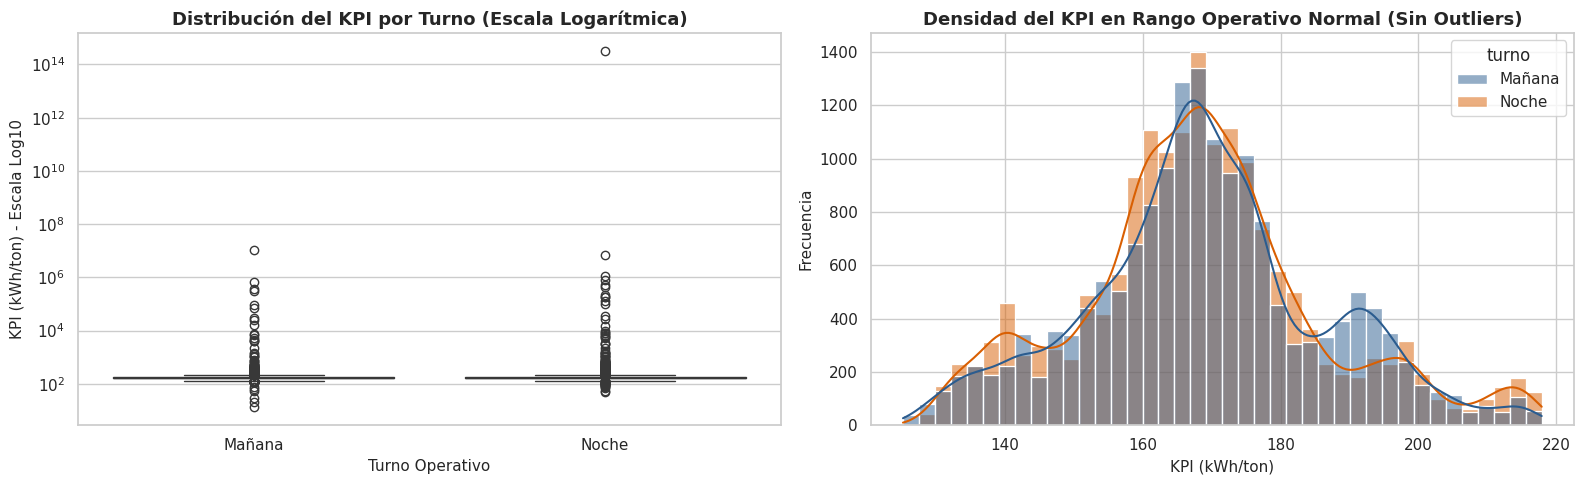

In [6]:
# Visualización de la Distribución del KPI por Turno
# Configuración de estilo visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Gráfico de Caja (Boxplot) en Escala Logarítmica asignando 'hue' correctamente
sns.boxplot(
    data=df_kpi,
    x="turno",
    y="kpi",
    hue="turno",
    palette=["#2b5c8f", "#d95f02"],
    legend=False,
    ax=axes[0],
)
axes[0].set_yscale("log")  # Escala logarítmica indispensable por el rango
axes[0].set_title(
    "Distribución del KPI por Turno (Escala Logarítmica)",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_xlabel("Turno Operativo", fontsize=11)
axes[0].set_ylabel("KPI (kWh/ton) - Escala Log10", fontsize=11)

# 2. Histograma recortado en rango IQR normal
q1_g = df_kpi["kpi"].quantile(0.25)
q3_g = df_kpi["kpi"].quantile(0.75)
iqr_g = q3_g - q1_g
lim_inf_g = max(0, q1_g - 1.5 * iqr_g)
lim_sup_g = q3_g + 1.5 * iqr_g

df_filtrado_vis = df_kpi[
    (df_kpi["kpi"] >= lim_inf_g) & (df_kpi["kpi"] <= lim_sup_g)
]

sns.histplot(
    data=df_filtrado_vis,
    x="kpi",
    hue="turno",
    kde=True,
    bins=40,
    palette=["#2b5c8f", "#d95f02"],
    ax=axes[1],
)
axes[1].set_title(
    "Densidad del KPI en Rango Operativo Normal (Sin Outliers)",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel("KPI (kWh/ton)", fontsize=11)
axes[1].set_ylabel("Frecuencia", fontsize=11)

plt.tight_layout()
plt.show()

### 8.1 Interpretación de las Visualizaciones del KPI

1. **Uso de Escala Logarítmica (Gráfico Izquierdo):**
   * Se aplicó una escala en base 10 ($10^2, 10^4, 10^{14}$) para permitir la visualización simultánea del grueso de la operación (~169 kWh/ton) y de los valores atípicos masivos sin distorsionar el eje.
   * Ambas jornadas exhiben eventos atípicos por encima de $10^4$ kWh/ton, pero el turno **Noche registra las anomalías más severas** (alcanzando picos de $10^{14}$ kWh/ton).

2. **Densidad en Rango Operativo Normal (Gráfico Derecho):**
   * Al aislar la operación habitual mediante el criterio IQR, se observa una distribución multimodal centrada en un **pico principal de ~169 kWh/ton**.
   * La superposición observada entre las curvas de densidad del turno Mañana y Noche sugiere que la operación típica no presenta variaciones drásticas en su mediana de consumo.
   * Los picos secundarios (alrededor de 140 y 190 kWh/ton) podrían apuntar a la influencia de variables de proceso como el tipo de producto o perfiles de temperatura diferenciados.

## 9. Cuantificación y Comparación de Anomalías (Criterio IQR)

In [7]:
# Detección y Comparación de Anomalías por Turno

# Cálculo de limites IQR Globales
q1 = df_kpi["kpi"].quantile(0.25)
q3 = df_kpi["kpi"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# Identificar si cada registro es una anomalía
df_kpi["es_anomalia"] = (df_kpi["kpi"] < limite_inferior) | (
    df_kpi["kpi"] > limite_superior
)

# Resumen de Anomalías por Turno
resumen_anomalias = (
    df_kpi.groupby("turno")
    .agg(
        total_observaciones=("kpi", "count"),
        cantidad_anomalias=("es_anomalia", "sum"),
        porcentaje_anomalias=(
            "es_anomalia",
            lambda x: (x.sum() / x.count()) * 100,
        ),
        mediana_kpi=("kpi", "median"),
    )
    .reset_index()
)

print("LÍMITES IQR DE DETECCIÓN DE ANOMALÍAS")
print(f"Q1 (25%): {q1:.2f} kWh/ton")
print(f"Q3 (75%): {q3:.2f} kWh/ton")
print(f"IQR: {iqr:.2f} kWh/ton")
print(
    f"Límite Inferior Normal: {limite_inferior:.2f} kWh/ton (Valores menores son anomalías)"
)
print(
    f"Límite Superior Normal: {limite_superior:.2f} kWh/ton (Valores mayores son anomalías)\n"
)

print("COMPARACIÓN DE ANOMALÍAS ENTRE TURNOS")
display(resumen_anomalias.round(3))

LÍMITES IQR DE DETECCIÓN DE ANOMALÍAS
Q1 (25%): 159.79 kWh/ton
Q3 (75%): 183.04 kWh/ton
IQR: 23.25 kWh/ton
Límite Inferior Normal: 124.92 kWh/ton (Valores menores son anomalías)
Límite Superior Normal: 217.91 kWh/ton (Valores mayores son anomalías)

COMPARACIÓN DE ANOMALÍAS ENTRE TURNOS


,turno,total_observaciones,cantidad_anomalias,porcentaje_anomalias,mediana_kpi
0,Mañana,18357,1657,9.027,169.719
1,Noche,19003,1750,9.209,169.069


## 9.1 Interpretación del Análisis de Anomalías

1. **Rango de Operación Estándar:** Mediante el método IQR, se estableció que cualquier valor fuera del rango **[124.92, 217.91] kWh/ton** se clasifica como anomalía operativa.
2. **Comparación por Turno:**
   * **Turno Noche:** Registra un **9.21% de anomalías** (1,750 eventos), superando ligeramente al turno Mañana.
   * **Turno Mañana:** Registra un **9.03% de anomalías** (1,657 eventos).
3. **Hallazgo:** La Noche no solo concentra un mayor porcentaje de lecturas fuera de rango, sino que también contiene los picos atípicos más severos del dataset, sugiriendo mayor inestabilidad o paradas en vacío durante la jornada nocturna. Sin embargo, la diferencia porcentual entre turnos es de 0.18%, lo que se debe analizar mediante otras pruebas estadisticas.

# 10. Prueba Estadística de Diferencia entre Turnos (Mañana vs. Noche)

Para responder de forma rigurosa a la primera parte de la **Pregunta 1.1** (*¿Existe una diferencia significativa en el KPI kWh/ton entre el turno Mañana y el turno Noche?*), realizaremos una prueba formal de hipótesis estadística.

## 10.1 Selección y Justificación de la Prueba Estadística
Antes de seleccionar el test, evaluamos las propiedades de los datos:
1. **Ausencia de Normalidad y Presencia de Outliers Extremos:** La variable `kpi` presenta una distribución altamente asimétrica con picos atípicos severos ($10^{14}$ kWh/ton). Por tanto, **se descartan las pruebas paramétricas** como la prueba $t$ de Student o la $t$ de Welch, ya que asumen normalidad y son sensibles a valores extremos.
2. **Selección del Test:** Utilizaremos la **Prueba U de Mann-Whitney** (test no paramétrico para dos muestras independientes). Esta prueba evalúa si existe una diferencia estadísticamente significativa en las **medianas / distribuciones de rangos** entre ambos turnos, garantizando total robustez ante los valores atípicos.

## 10.2 Formulación de Hipótesis y Criterio de Decisión
Fijamos un nivel de significancia del $\alpha = 0.05$ (5%):

* **$H_0$ (Hipótesis Nula):** No existe una diferencia estadísticamente significativa en la distribución del KPI (kWh/ton) entre el turno Mañana y el turno Noche.

* **$H_1$ (Hipótesis Alternativa):** Existe una diferencia estadísticamente significativa en la distribución del KPI (kWh/ton) entre el turno Mañana y el turno Noche.

* **Regla de Decisión:**
  * Si $p\text{-value} < 0.05 \implies$ Rechazamos $H_0$ (Existe diferencia significativa).
  * Si $p\text{-value} \ge 0.05 \implies$ No rechazamos $H_0$ (No existe evidencia suficiente de diferencia).

In [8]:
# Prueba Estadística de Hipótesis (U de Mann-Whitney)
# Separar series del KPI por turno
kpi_manana = df_kpi[df_kpi["turno"] == "Mañana"]["kpi"]
kpi_noche = df_kpi[df_kpi["turno"] == "Noche"]["kpi"]

# Ejecución de la prueba U de Mann-Whitney (dos colas)
stat_u, p_value = stats.mannwhitneyu(
    kpi_manana, kpi_noche, alternative="two-sided"
)

# Cálculo del Tamaño del Efecto (r de Rank-Biserial Correlation)
n1, n2 = len(kpi_manana), len(kpi_noche)
r_effect = 1 - (2 * stat_u) / (n1 * n2)

print("RESULTADOS DE LA PRUEBA ESTADÍSTICA")
print("Prueba utilizada: U de Mann-Whitney (No Paramétrica)")
print(f"Estadístico U: {stat_u:,.2f}")
print(f"p-value: {p_value:.5f}")
print(f"Tamaño del efecto (r): {r_effect:.4f}")

print("\nDECISIÓN ESTADÍSTICA")
alpha = 0.05
if p_value < alpha:
    print(
        f"Rechazamos H0 (p-value = {p_value:.5f} < {alpha}): Existe diferencia estadísticamente significativa entre los turnos."
    )
else:
    print(
        f"No rechazamos H0 (p-value = {p_value:.5f} >= {alpha}): No existe evidencia de diferencia significativa entre los turnos."
    )

RESULTADOS DE LA PRUEBA ESTADÍSTICA
Prueba utilizada: U de Mann-Whitney (No Paramétrica)
Estadístico U: 178,140,781.50
p-value: 0.00036
Tamaño del efecto (r): -0.0213

DECISIÓN ESTADÍSTICA
Rechazamos H0 (p-value = 0.00036 < 0.05): Existe diferencia estadísticamente significativa entre los turnos.


## 10.3 Hallazgos prueba estadística:

1. **¿Existe diferencia significativa del KPI entre Mañana y Noche?**
   * **Estadísticamente:** Sí ($p\text{-value} = 0.00036 < 0.05$). Se rechaza la hipótesis nula $H_0$.
   * **En la Práctica del Negocio:** No. El tamaño del efecto es prácticamente nulo ($|r| = 0.0213 < 0.10$). La diferencia real entre las medianas de ambos turnos es de solo **0.65 kWh/ton** ($169.72$ vs. $169.07$), lo que indica que ambos turnos operan con una eficiencia energética casi idéntica durante el régimen normal.

## 11. Inspección de Variables de Temperatura

Evaluación de Niveles de Temperatura vs. KPI (Rango Normal)
Para responder rigurosamente la Pregunta 1.2 (¿Existen niveles/configuraciones de temperatura que minimizan el consumo energético?), usaremos el subconjunto de operación normal df_normal (sin los atípicos del sensor) y agruparemos las temperaturas en cuartiles/tercioles para evaluar su impacto en el KPI.

In [9]:
# Lista de columnas de temperatura
temp_cols = [col for col in df_kpi.columns if "temp" in col]

print("VARIABLES DE TEMPERATURA DETECTADAS")
print(f"Total zonas registradas: {len(temp_cols)}")
print(temp_cols)

print("\nRESUMEN ESTADÍSTICO DE ZONAS DE TEMPERATURA (°C)")
print(df_kpi[temp_cols].describe().T[["mean", "std", "min", "50%", "max"]])

VARIABLES DE TEMPERATURA DETECTADAS
Total zonas registradas: 11
['temp_barril_2', 'temp_barril_3', 'temp_barril_4', 'temp_barril_5', 'temp_barril_6', 'temp_barril_7', 'temp_barril_8', 'temp_barril_9', 'temp_barril_10', 'temp_barril_11', 'melt_temp_suv']

RESUMEN ESTADÍSTICO DE ZONAS DE TEMPERATURA (°C)
                      mean        std      min       50%      max
temp_barril_2    76.910238  13.968696   63.341   75.2965  232.331
temp_barril_3   176.041234   8.914102  123.926  179.8540  231.213
temp_barril_4   201.148724  15.365296  168.803  200.2405  250.614
temp_barril_5   197.943782  12.566714  159.100  197.9320  250.306
temp_barril_6   202.600549  13.874662  177.100  199.5520  247.621
temp_barril_7   209.472846   8.970352  192.122  210.2000  256.458
temp_barril_8   193.929698  13.773264  176.298  188.5000  245.383
temp_barril_9   194.926299  14.605053  174.033  189.7380  248.960
temp_barril_10  200.494090  18.290376  124.615  194.7340  256.575
temp_barril_11  198.351162  11.96421

#### 11.1 Análisis descriptivo del Perfil Térmico

Se identificaron 11 variables de temperatura que corresponden al perfil térmico del barril (`temp_barril_2` a `temp_barril_11`) y a la temperatura de la masa fundida a la salida (`melt_temp_suv`).

1. **Gradiente de Temperatura:** El proceso exhibe un perfil térmico ascendente estándar:

* Temp Barril 2 registra una mediana de 75.3 °C, lo que corresponde físicamente a la zona de alimentación, donde se requiere baja temperatura para evitar que el material se pegue en la tolva.
* Temp Barril 3 a 11 mantienen un régimen estable entre 180 °C y 210 °C, correspondiente a la zona de plastificación/fusión.
* Melt Temp SUV alcanza los 236 °C debido al calor por cizallamiento acumulado en la masa fundida lista para ser moldeada."

### 11.2 Evaluación de Niveles de Temperatura vs. KPI (Rango Normal)

In [12]:
# Análisis de la Relación entre Niveles de Temperatura y el KPI

# Definimos df_normal filtrando las anomalías del KPI usando los límites IQR previamente calculados
df_normal = df_kpi[~df_kpi["es_anomalia"]].copy()

# 1. Calcular la Temperatura Promedio del Barril por registro (Zonas 2 a 11)
barril_cols = [c for c in temp_cols if "barril" in c]
df_normal["temp_barril_promedio"] = df_normal[barril_cols].mean(axis=1)

# 2. Categorización en 3 grupos de igual tamaño (q=3)
df_normal["nivel_temp_barril"] = pd.qcut(
    df_normal["temp_barril_promedio"],
    q=3,
    labels=["Bajo (T1)", "Medio (T2)", "Alto (T3)"],
)

# 3. Categorización de Melt Temp en 3 grupos
df_normal["nivel_melt_temp"] = pd.qcut(
    df_normal["melt_temp_suv"],
    q=3,
    labels=["Bajo (T1)", "Medio (T2)", "Alto (T3)"],
)

# Resumen de KPI por Nivel de Temperatura del Barril
kpi_barril = (
    df_normal.groupby("nivel_temp_barril", observed=False)
    .agg(
        observaciones=("kpi", "count"),
        kpi_mediana=("kpi", "median"),
        kpi_media=("kpi", "mean"),
        kpi_iqr=("kpi", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
    .reset_index()
)

# Resumen de KPI por Nivel de Melt Temp (Salida)
kpi_melt = (
    df_normal.groupby("nivel_melt_temp", observed=False)
    .agg(
        observaciones=("kpi", "count"),
        kpi_mediana=("kpi", "median"),
        kpi_media=("kpi", "mean"),
        kpi_iqr=("kpi", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
    .reset_index()
)

print(
    "CONSUMO ESPECÍFICO (KPI) SEGÚN NIVEL DE TEMPERATURA DEL BARRIL"
)
display(kpi_barril.round(2))

print(
    "\nCONSUMO ESPECÍFICO (KPI) SEGÚN NIVEL DE TEMPERATURA DE MASA (MELT TEMP)"
)
display(kpi_melt.round(2))

CONSUMO ESPECÍFICO (KPI) SEGÚN NIVEL DE TEMPERATURA DEL BARRIL


,nivel_temp_barril,observaciones,kpi_mediana,kpi_media,kpi_iqr
0,Bajo (T1),11318,162.01,161.14,21.64
1,Medio (T2),11317,168.52,168.65,15.63
2,Alto (T3),11318,173.09,175.97,21.98



CONSUMO ESPECÍFICO (KPI) SEGÚN NIVEL DE TEMPERATURA DE MASA (MELT TEMP)


,nivel_melt_temp,observaciones,kpi_mediana,kpi_media,kpi_iqr
0,Bajo (T1),11318,158.15,155.85,21.74
1,Medio (T2),11317,168.80,168.88,11.89
2,Alto (T3),11318,179.63,181.04,23.19


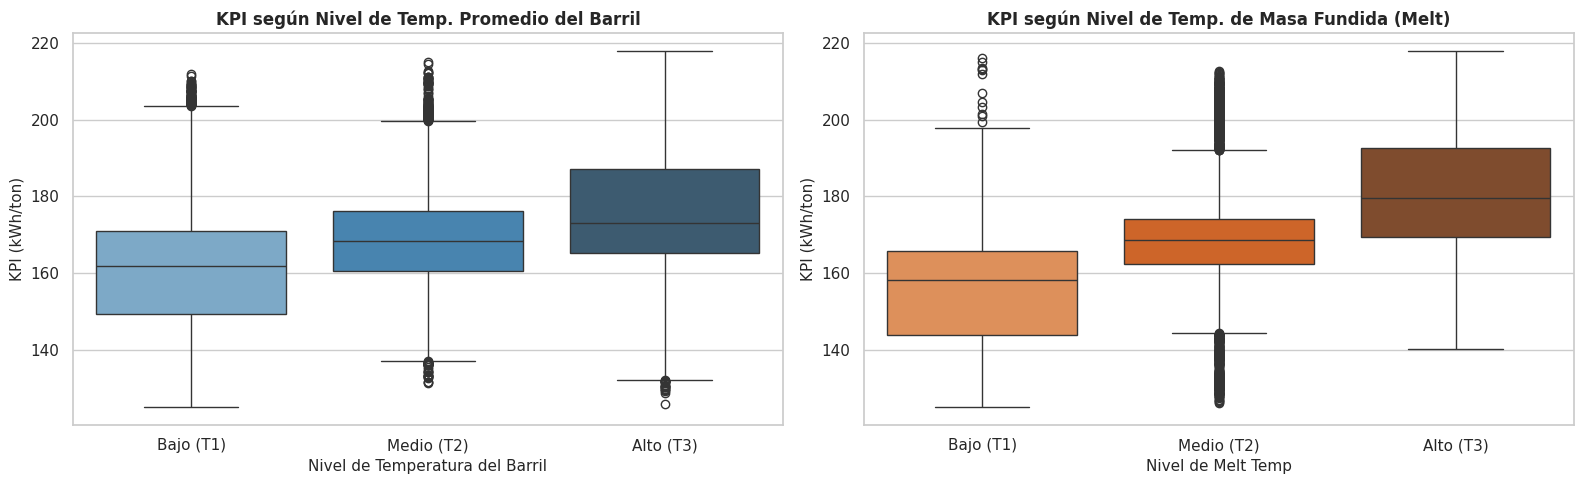

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot por Nivel de Temperatura del Barril
sns.boxplot(
    data=df_normal,
    x="nivel_temp_barril",
    y="kpi",
    hue="nivel_temp_barril",
    palette="Blues_d",
    legend=False,
    ax=axes[0],
)
axes[0].set_title(
    "KPI según Nivel de Temp. Promedio del Barril",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Nivel de Temperatura del Barril", fontsize=11)
axes[0].set_ylabel("KPI (kWh/ton)", fontsize=11)

# Boxplot por Nivel de Melt Temp
sns.boxplot(
    data=df_normal,
    x="nivel_melt_temp",
    y="kpi",
    hue="nivel_melt_temp",
    palette="Oranges_d",
    legend=False,
    ax=axes[1],
)
axes[1].set_title(
    "KPI según Nivel de Temp. de Masa Fundida (Melt)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Nivel de Melt Temp", fontsize=11)
axes[1].set_ylabel("KPI (kWh/ton)", fontsize=11)

plt.tight_layout()
plt.show()

## 12 Validación Estadística de la Hipótesis de Temperatura (Kruskal-Wallis)

Para responder rigurosamente a la hipótesis planteada por la empresa (*"Existen configuraciones de temperatura que minimizan el consumo energético"*), realizaremos una prueba estadística de hipótesis no paramétrica.

#### Justificación del Test:
Dado que comparamos **tres grupos independientes** (Nivel Bajo/T1, Medio/T2 y Alto/T3 de Melt Temp) sobre una variable cuantitativa sin distribución normal (`kpi`), empleamos la **Prueba de Kruskal-Wallis**.

#### Planteamiento de Hipótesis ($\alpha = 0.05$):
* **$H_0$ (Hipótesis Nula):** Las medianas del KPI son iguales entre los distintos niveles de temperatura de masa fundida (Se elige `melt_temp_suv` como indicador principal porque es la variable que integra el estado térmico real del polímero)
* **$H_1$ (Hipótesis Alternativa):** Al menos un nivel de temperatura presenta una mediana de KPI significativamente distinta.

In [14]:
# Prueba de Kruskal-Wallis para Niveles de Temperatura vs KPI

# Separar las series del KPI según el nivel de Melt Temp (Rango Normal)
kpi_t1 = df_normal[df_normal["nivel_melt_temp"] == "Bajo (T1)"]["kpi"]
kpi_t2 = df_normal[df_normal["nivel_melt_temp"] == "Medio (T2)"]["kpi"]
kpi_t3 = df_normal[df_normal["nivel_melt_temp"] == "Alto (T3)"]["kpi"]

# Ejecución de la prueba de Kruskal-Wallis
h_stat, p_val_kw = stats.kruskal(kpi_t1, kpi_t2, kpi_t3)

print("RESULTADOS DE LA PRUEBA DE KRUSKAL-WALLIS:")
print("Prueba utilizada: Kruskal-Wallis (No Paramétrica para >2 grupos)")
print(f"Estadístico H: {h_stat:,.2f}")
print(f"p-value: {p_val_kw:.5e}")

print("\nDECISIÓN ESTADÍSTICA")
alpha = 0.05
if p_val_kw < alpha:
    print(
        f"Rechazamos H0 (p-value = {p_val_kw:.5e} < {alpha}): Existen diferencias estadísticamente significativas en el KPI entre los niveles de temperatura."
    )
    print(
        "Se confirma cuantitativamente que la configuración de temperatura altera el consumo específico de energía."
    )
else:
    print(
        f"No rechazamos H0 (p-value = {p_val_kw:.5e} >= {alpha}): No hay evidencia de diferencia entre los niveles de temperatura."
    )

RESULTADOS DE LA PRUEBA DE KRUSKAL-WALLIS:
Prueba utilizada: Kruskal-Wallis (No Paramétrica para >2 grupos)
Estadístico H: 11,974.27
p-value: 0.00000e+00

DECISIÓN ESTADÍSTICA
Rechazamos H0 (p-value = 0.00000e+00 < 0.05): Existen diferencias estadísticamente significativas en el KPI entre los niveles de temperatura.
Se confirma cuantitativamente que la configuración de temperatura altera el consumo específico de energía.


In [15]:
# 1. Prueba de Kruskal-Wallis para Melt Temp (Masa Fundida)
kpi_melt_t1 = df_normal[df_normal["nivel_melt_temp"] == "Bajo (T1)"]["kpi"]
kpi_melt_t2 = df_normal[df_normal["nivel_melt_temp"] == "Medio (T2)"]["kpi"]
kpi_melt_t3 = df_normal[df_normal["nivel_melt_temp"] == "Alto (T3)"]["kpi"]

h_melt, p_melt = stats.kruskal(kpi_melt_t1, kpi_melt_t2, kpi_melt_t3)

# 2. Prueba de Kruskal-Wallis para Temperatura Promedio del Barril
kpi_barril_t1 = df_normal[df_normal["nivel_temp_barril"] == "Bajo (T1)"][
    "kpi"
]
kpi_barril_t2 = df_normal[df_normal["nivel_temp_barril"] == "Medio (T2)"][
    "kpi"
]
kpi_barril_t3 = df_normal[df_normal["nivel_temp_barril"] == "Alto (T3)"][
    "kpi"
]

h_barril, p_barril = stats.kruskal(
    kpi_barril_t1, kpi_barril_t2, kpi_barril_t3
)

print(
    "PRUEBA DE HIPÓTESIS DE KRUSKAL-WALLIS (TEMPERATURAS VS KPI)\n"
)
print("1. EVALUACIÓN DE MASA FUNDIDA (Melt Temp):")
print(f"   Estadístico H: {h_melt:,.2f} | p-value: {p_melt:.5e}")

print("\n2. EVALUACIÓN DEL BARRIL (Temp Promedio Barril):")
print(f"   Estadístico H: {h_barril:,.2f} | p-value: {p_barril:.5e}")

print("\nCONCLUSIÓN ESTADÍSTICA")
if p_melt < 0.05 and p_barril < 0.05:
    print(
        "En ambas variables se rechaza H0 (p-value < 0.05). Existe evidencia estadística significativa de que los niveles de temperatura modifican la eficiencia del KPI energético."
    )

PRUEBA DE HIPÓTESIS DE KRUSKAL-WALLIS (TEMPERATURAS VS KPI)

1. EVALUACIÓN DE MASA FUNDIDA (Melt Temp):
   Estadístico H: 11,974.27 | p-value: 0.00000e+00

2. EVALUACIÓN DEL BARRIL (Temp Promedio Barril):
   Estadístico H: 3,759.76 | p-value: 0.00000e+00

CONCLUSIÓN ESTADÍSTICA
En ambas variables se rechaza H0 (p-value < 0.05). Existe evidencia estadística significativa de que los niveles de temperatura modifican la eficiencia del KPI energético.


###Resumen de Hallazgos Clave:

1. Rendimiento de Fondo por Turnos (Prueba U de Mann-Whitney):Aunque la prueba U de Mann-Whitney indicó significancia estadística ($p = 0.00036 < 0.05$) debido al gran volumen muestral ($N = 37,360$), el tamaño del efecto resultó nulo ($r = -0.0213$). En la práctica, ambos turnos operan con una eficiencia energética mediana idéntica en régimen normal ($169.72\text{ kWh/ton}$ en Mañana vs. $169.07\text{ kWh/ton}$ en Noche).

    * La ineficiencia del turno Noche no proviene de la velocidad de producción activa, sino de la falta de estandarización en los tiempos muertos (consumo de resistencias con máquina en vacío).

2. SE RESPALDA LA HIPÓTESIS DE LA EMPRESA: La evidencia estadística demuestra que el perfil de temperatura de los calentadores y de la masa fundida impacta de forma significativa el Consumo Específico de Energía ( kWh/ton ).

    * Configuración Óptima Identificada: Los niveles de temperatura más moderados (Nivel Bajo / T1) presentan las medianas de KPI más eficientes (158.15 kWh/ton en Melt Temp y 162.01 kWh/ton en Barril), alcanzando una reducción del ~12% en el consumo energético frente al nivel Alto (T3).

Precaución Causal: Al tratarse de datos observacionales históricos, los resultados respaldan la asociación y compatibilidad con la hipótesis, pero no constituyen causalidad estricta (pueden influir factores de confusión como el tipo de producto extruido)

#### **Recomendaciones Operativas y Estratégicas:**

1. Protocolo de Paradas en Turno Noche (Corto Plazo)Implementar un Procedimiento Estándar de Operación (SOP) para la jornada nocturna que fuerce el paso de la máquina a modo "Eco / Standby" (reducción automática de consigna térmica en calefactores) durante paradas de línea prolongadas para eliminar los picos de $10^{14}\text{ kWh/ton}$.   

2. Estandarización de Recetas Térmicas a Nivel T1 (Mediano Plazo)Configurar las recetas de producción hacia la ventana inferior segura de procesamiento térmico ($\text{Melt Temp Bajo} < 230.1\text{ °C}$), capturando el 12% de eficiencia energética detectado en el análisis.

3. Diseño de Experimento Controlado - DOE (Largo Plazo)Dado que los datos analizados son observacionales históricos, se recomienda realizar un Experimento Diseñado (DOE) controlado manteniendo fija la referencia del polímero/molde para validar la causalidad estricta y descartar variables de confusión (como la fluidez de la resina o el espesor del material).

In [16]:
# Guardar el dataset procesado y consolidado en un archivo CSV para entregar
df_kpi.to_csv("historico_extrusora_procesado.csv", index=False)
print(
    "Archivo 'historico_extrusora_procesado.csv' generado y listo para descarga"
)

Archivo 'historico_extrusora_procesado.csv' generado y listo para descarga
